In [2]:
from Bio import SeqIO, pairwise2
from Bio.SeqUtils import MeltingTemp as mt, molecular_weight as mw, gc_fraction
from Bio.Seq import Seq
from matplotlib import pyplot as plt
from Levenshtein import distance
from Bio.pairwise2 import format_alignment
from collections import Counter

## Sequence Manipulation

A. Count the number of times the codon (CGG) appears in Sequence A and B.

In [5]:
SeqA = SeqIO.read('./U61535.fasta', 'fasta')
SeqB = SeqIO.read('./U88957.fasta', 'fasta')

CGG_seqA = SeqA.count('CGG')
CGG_seqB = SeqB.count('CGG')

B. Display the length of both Sequence A and Sequence B combined.

In [9]:
LenA = len(SeqA)
LenB = len(SeqB)

LenSum = LenA + LenB

print(LenA)
print(LenB)
print(LenSum)

2373
2521
4894


C. Take the last 15 nucleotides from Sequence A and the first 35 nucleotides from Sequence B then combine the sequences into a new sequence, Sequence C.

In [55]:
SeqC = SeqA[-15:] + SeqB[:35]

## Sequence Analysis & Plotting

A. Determine and display the nucleotides base (A, C, G, T) frequency for Sequence A, B, and C with a chart using matplotlib library.

<function matplotlib.pyplot.show(close=None, block=None)>

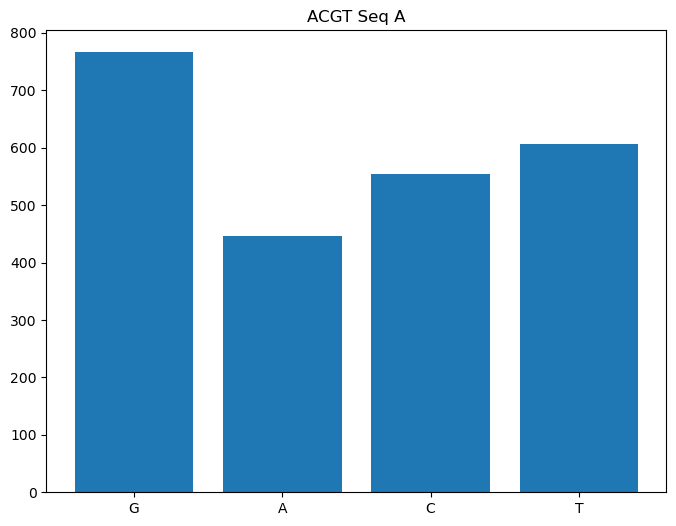

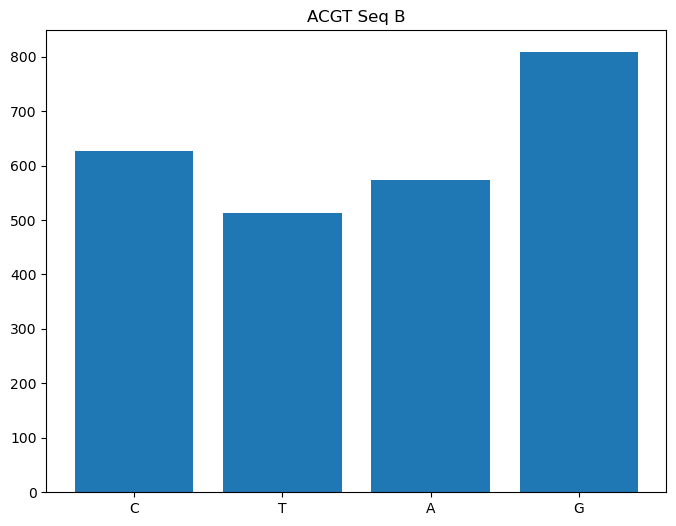

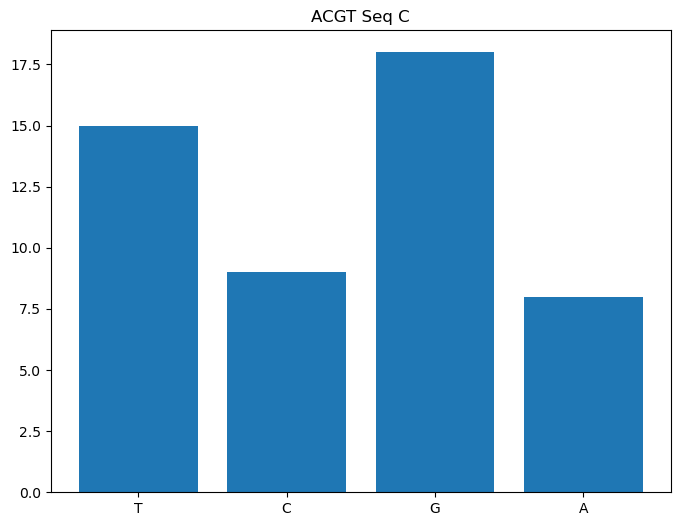

In [28]:
CounterA = Counter(SeqA)
CounterB = Counter(SeqB)
CounterC = Counter(SeqC)

plt.figure(figsize=(8,6))
plt.bar(CounterA.keys(), CounterA.values())
plt.title('ACGT Seq A')
plt.show

plt.figure(figsize=(8,6))
plt.bar(CounterB.keys(), CounterB.values())
plt.title('ACGT Seq B')
plt.show

plt.figure(figsize=(8,6))
plt.bar(CounterC.keys(), CounterC.values())
plt.title('ACGT Seq C')
plt.show

B. Determine and display the GC & AT content percentage for Sequence A, B, and C.

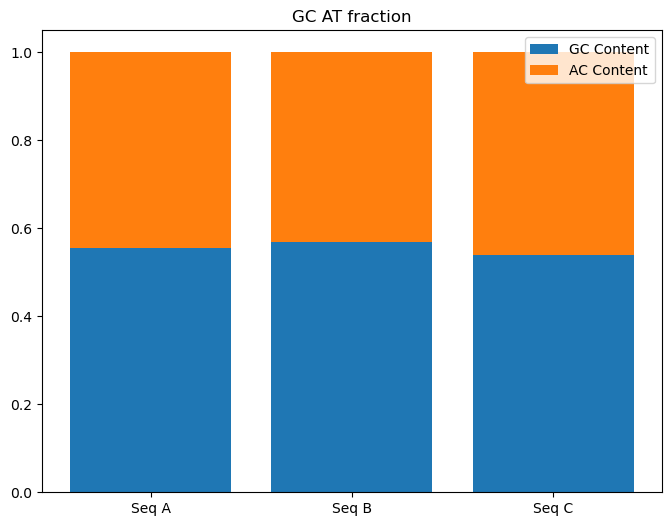

In [41]:
GC_seqA = gc_fraction(SeqA)
GC_seqB = gc_fraction(SeqB)
GC_seqC = gc_fraction(SeqC)

AT_seqA = 1 - GC_seqA
AT_seqB = 1 - GC_seqB
AT_seqC = 1 - GC_seqC

labels = ['Seq A', 'Seq B', 'Seq C']
gc_percentages = [GC_seqA, GC_seqB, GC_seqC]
at_percentages = [AT_seqA, AT_seqB, AT_seqC]

plt.figure(figsize=(8,6))
plt.title('GC AT fraction')
plt.bar(labels, gc_percentages, label='GC Content')
plt.bar(labels, at_percentages, bottom=gc_percentages, label='AC Content')
plt.legend()
plt.show()


C. Determine and display the melting temperature for Sequence A, B, and C (using built-in Wallace Method).

In [45]:
mtA = mt.Tm_Wallace(SeqA, strict=False)
mtB = mt.Tm_Wallace(SeqB, strict=False)
mtC = mt.Tm_Wallace(SeqC, strict=False)

print(mtA, mtB, mtC)

417.0 346.0 154.0


D. Determine and display the molecular weight for Sequence A, B, and C.

In [46]:
mwA = mw(SeqA)
mwB = mw(SeqB)
mwC = mw(SeqC)

print(mwA, mwB, mwC)

736731.8233000102 782875.8319000122 15614.9077


## DNA & mRNA Protein Synthesis

A. Transcribe and display the DNA Sequence A, B, and C into mRNA Sequences.

In [58]:
mrna_A = SeqA.seq.transcribe()
mrna_B = SeqB.seq.transcribe()
mrna_C = SeqC.seq.transcribe()


B. Translate and display the mRNA Sequence A, B, and C into amino acids sequences.

In [57]:
aminoAcid_A = mrna_A.translate()
aminoAcid_B = mrna_B.translate()
aminoAcid_C = mrna_C.translate()

/home/adriel/miniconda3/envs/compbio/lib/python3.11/site-packages/Bio/Seq.py:2877: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


## Sequence Alignment & Similarities

A. Take the first 100 nucleotides from Sequence A to make Sequence D and the first 100 nucleotides from Sequence B to make Sequence E.

In [61]:
SeqD = SeqA.seq[:100]
SeqE = SeqB.seq[:100]

B. Perform local alignment pairwise between Sequence D and Sequence “GCATGTAGCTAGCATCAGCTAC” and display the alignments’ score.

In [ ]:
seq1 = Seq('GCATGTAGCTAGCATCAGCTAC')
seq2 = Seq('ATGCTAGTCGATCATTATTAGC')

alignmentD = pairwise2.align.localxx(SeqD,seq1)

for align in alignmentD:
    print(format_alignment(*align))

10 GTCCACTTCTTGCCTCTTGCGCGGTGCTGTGCGGTAAAAGAGGGGGCGTCGCGTTCGAGTAAAATTTTC-TCTTAAGCCTTAAGTGAGATAC
   |  ||                        |   ||     |         ||  |  ||         | ||   || |          |||
 1 G--CA------------------------T---GT-----A---------GC--T--AG---------CATC---AG-C----------TAC
  Score=21

9 GGTCCACTTCTTGCCTCTTGCGCGGTGCTGTGCGGTAAAAGAGGGGGCGTCGCGTTCGAGTAAAATTTTC-TCTTAAGCCTTAAGTGAGATAC
  |   ||                        |   ||     |         ||  |  ||         | ||   || |          |||
1 G---CA------------------------T---GT-----A---------GC--T--AG---------CATC---AG-C----------TAC
  Score=21

7 GTGGTCCACTTCTTGCCTCTTGCGCGGTGCTGTGCGGTAAAAGAGGGGGCGTCGCGTTCGAGTAAAATTTTC-TCTTAAGCCTTAAGTGAGATAC
  |     ||                        |   ||     |         ||  |  ||         | ||   || |          |||
1 G-----CA------------------------T---GT-----A---------GC--T--AG---------CATC---AG-C----------TAC
  Score=21

5 GTGTGGTCCACTTCTTGCCTCTTGCGCGGTGCTGTGCGGTAAAAGAGGGGGCGTCGCGTTCGAGTAAAATTTTC-TCTTAAGCCTTAAGTGA

C. Perform local alignment pairwise between Sequence E and Sequence “ATGCTAGTCGATCATTATTAGC” and display the alignments’ score.

In [65]:
alignmentE = pairwise2.align.localxx(SeqE, seq2)

for align in alignmentE:
    print(format_alignment(*align))

21 ATTGGGCAGTAGTGTTAGAAAA-GAAGGGTGAGGGGGCTACTAGACAGGGCCGGGGGGGGGGGGTGAGGT-AGC
   | |  ||  ||  | |       | |   |       | | |                      | |  | |||
 1 A-T--GC--TA--G-T------CG-A---T-------C-A-T----------------------T-A--TTAGC
  Score=20

15 ACCTTGATTGGGCAGTAGTGTTAGAAAA-GAAGGGTGAGGGGGCTACTAGACAGGGCCGGGGGGGGGGGGTGAGGT-AGC
   |       |  ||  ||  | |       | |   |       | | |                      | |  | |||
 1 A-------T--GC--TA--G-T------CG-A---T-------C-A-T----------------------T-A--TTAGC
  Score=20

13 ATACCTTGATTGGGCAGTAGTGTTAGAAAA-GAAGGGTGAGGGGGCTACTAGACAGGGCCGGGGGGGGGGGGTGAGGT-AGC
   |         |  ||  ||  | |       | |   |       | | |                      | |  | |||
 1 A---------T--GC--TA--G-T------CG-A---T-------C-A-T----------------------T-A--TTAGC
  Score=20

7 AGCTGGATACCTTGATTGGGCAGTAGTGTTAGAAAA-GAAGGGTGAGGGGGCTACTAGACAGGGCCGGGGGGGGGGGGTGAGGT-AGC
  |               |  ||  ||  | |       | |   |       | | |                      | |  | |||
1 A---------------T--GC--TA--G-T------

D. Find and display the Levenshtein distance between Sequence D and E.

In [66]:
distance(SeqD, SeqE)

60